# Analyse du marché immobilier toulousain — Ymmo
**Source** : Demandes de Valeurs Foncières (DVF) — data.gouv.fr  
**Commune** : Toulouse (31555) — Année 2025  
**Objectifs** :
- Nettoyage et préparation des données
- Analyses statistiques du marché
- Biens populaires et zones attractives
- Prédiction du prix au m²

## 1. Chargement et exploration initiale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
NAVY  = '#0F1C2E'
CLAY  = '#D45A1A'
SLATE = '#8FA3B8'
COLORS = [NAVY, CLAY, SLATE, '#2E6DA4', '#4CAF50', '#FF9800']

df_raw = pd.read_csv('31555.csv')
print(f'Dimensions brutes : {df_raw.shape}')
print(f'Période : {df_raw["date_mutation"].min()} → {df_raw["date_mutation"].max()}')
df_raw.head(3)

Dimensions brutes : (22592, 40)
Période : 2024-01-02 → 2024-12-31


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2024-333886,2024-01-05,1,Vente,141680.0,61.0,NaN,AV MAURICE BOURGES-MAUNOURY,5789,31200.0,...,Appartement,62.0,3.0,NaN,NaN,NaN,NaN,NaN,1.451601,43.639728
1,2024-333886,2024-01-05,1,Vente,141680.0,61.0,NaN,AV MAURICE BOURGES-MAUNOURY,5789,31200.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1.451601,43.639728
2,2024-333887,2024-01-05,1,Vente,85000.0,62.0,NaN,RUE DE PERIOLE,6760,31500.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,1.456960,43.615572


## 2. Nettoyage et préparation des données

In [2]:
print('=== Valeurs manquantes (%) ===')
missing = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(missing[missing > 0].round(1))

=== Valeurs manquantes (%) ===
ancien_code_commune             100.0
ancien_id_parcelle              100.0
ancien_nom_commune              100.0
lot5_surface_carrez             100.0
lot4_surface_carrez              99.9
lot3_surface_carrez              99.8
lot5_numero                      99.7
code_nature_culture_speciale     99.4
nature_culture_speciale          99.4
lot4_numero                      99.4
numero_volume                    99.2
lot3_numero                      98.2
lot2_surface_carrez              94.3
adresse_suffixe                  93.3
nature_culture                   81.6
code_nature_culture              81.6
surface_terrain                  81.6
lot2_numero                      81.6
lot1_surface_carrez              76.9
surface_reelle_bati              60.6
nombre_pieces_principales        20.2
type_local                       20.2
code_type_local                  20.2
lot1_numero                      19.1
adresse_numero                    4.7
longitude          

In [3]:
df = df_raw.copy()

df['date_mutation'] = pd.to_datetime(df['date_mutation'])
df['mois']      = df['date_mutation'].dt.month
df['trimestre'] = df['date_mutation'].dt.quarter
df['mois_nom']  = df['date_mutation'].dt.strftime('%b')

df = df[df['nature_mutation'] == 'Vente']
df = df[df['type_local'].isin(['Appartement', 'Maison'])]
df = df[df['valeur_fonciere'] > 10_000]
df = df[df['valeur_fonciere'] < 5_000_000]
df = df[df['surface_reelle_bati'] >= 9]
df = df[df['surface_reelle_bati'] <= 500]
df = df.dropna(subset=['valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales'])

df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle_bati']
df = df[(df['prix_m2'] > 500) & (df['prix_m2'] < 20_000)]

quartiers = {
    31000: 'Centre — Capitole',
    31100: 'Sud — Rangueil',
    31200: 'Nord — Les Minimes',
    31300: 'Ouest — Saint-Cyprien',
    31400: 'Est — Bonnefoy',
    31500: 'Nord-Est — Compans',
}
df['secteur'] = df['code_postal'].fillna(0).astype(int).map(quartiers).fillna('Autre')

print(f'Lignes brutes       : {len(df_raw):,}')
print(f'Lignes après filtre : {len(df):,}')
print(f'Types conservés     : {df["type_local"].value_counts().to_dict()}')
print(f'Prix m² médian      : {df["prix_m2"].median():,.0f} €/m²')

Lignes brutes       : 22,592
Lignes après filtre : 7,180
Types conservés     : {'Appartement': 6100, 'Maison': 1080}
Prix m² médian      : 3,363 €/m²


## 3. Analyses statistiques du marché

In [4]:
print('=== Statistiques générales ===')
stats = df.groupby('type_local').agg(
    nb_ventes       = ('id_mutation', 'count'),
    prix_moyen      = ('valeur_fonciere', 'mean'),
    prix_median     = ('valeur_fonciere', 'median'),
    surface_moyenne = ('surface_reelle_bati', 'mean'),
    prix_m2_moyen   = ('prix_m2', 'mean'),
    prix_m2_median  = ('prix_m2', 'median'),
).round(0)
print(stats.to_string())

=== Statistiques générales ===
             nb_ventes  prix_moyen  prix_median  surface_moyenne  prix_m2_moyen  prix_m2_median
type_local                                                                                     
Appartement       6100    204220.0     157220.0             55.0         3859.0          3286.0
Maison            1080    434373.0     362500.0            104.0         4303.0          3736.0


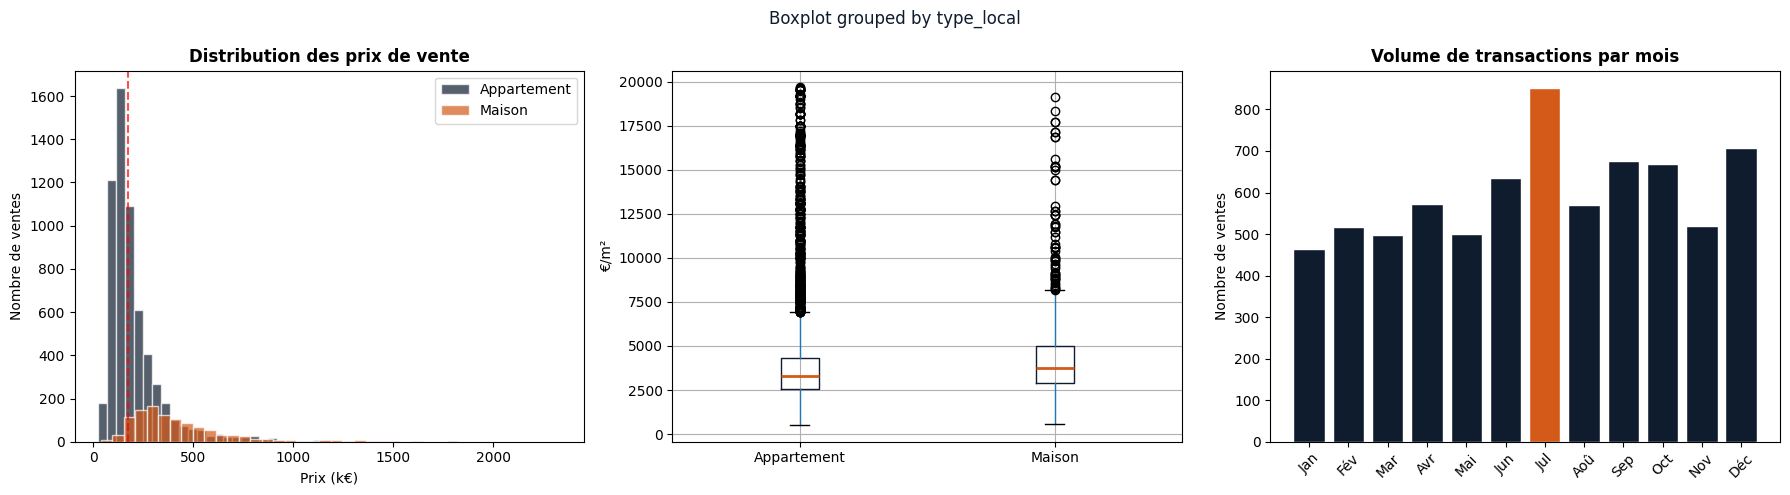

Mois le plus actif : Jul (851 ventes)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Marché immobilier toulousain 2025 — Vue générale', fontsize=14, fontweight='bold', color=NAVY)

# Distribution des prix
for i, (typ, color) in enumerate(zip(['Appartement', 'Maison'], [NAVY, CLAY])):
    subset = df[df['type_local'] == typ]['valeur_fonciere'] / 1000
    axes[0].hist(subset, bins=40, alpha=0.7, color=color, label=typ, edgecolor='white')
axes[0].set_title('Distribution des prix de vente', fontweight='bold')
axes[0].set_xlabel('Prix (k€)')
axes[0].set_ylabel('Nombre de ventes')
axes[0].legend()
axes[0].axvline(df['valeur_fonciere'].median()/1000, color='red', linestyle='--', alpha=0.7, label='Médiane')

# Prix m² par type
df.boxplot(column='prix_m2', by='type_local', ax=axes[1],
           boxprops=dict(color=NAVY), medianprops=dict(color=CLAY, linewidth=2))
axes[1].set_title('Prix au m² par type de bien', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('€/m²')
plt.sca(axes[1])
plt.title('')

# Nb ventes par mois
monthly = df.groupby('mois').size()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
axes[2].bar(range(1,13), [monthly.get(i,0) for i in range(1,13)], color=NAVY, edgecolor='white')
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(mois_labels, rotation=45)
axes[2].set_title('Volume de transactions par mois', fontweight='bold')
axes[2].set_ylabel('Nombre de ventes')
peak = monthly.idxmax()
axes[2].bar(peak, monthly[peak], color=CLAY, edgecolor='white')

plt.tight_layout()
plt.savefig('analyse_generale.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mois le plus actif : {mois_labels[peak-1]} ({monthly[peak]} ventes)')

## 4. Biens populaires et zones attractives

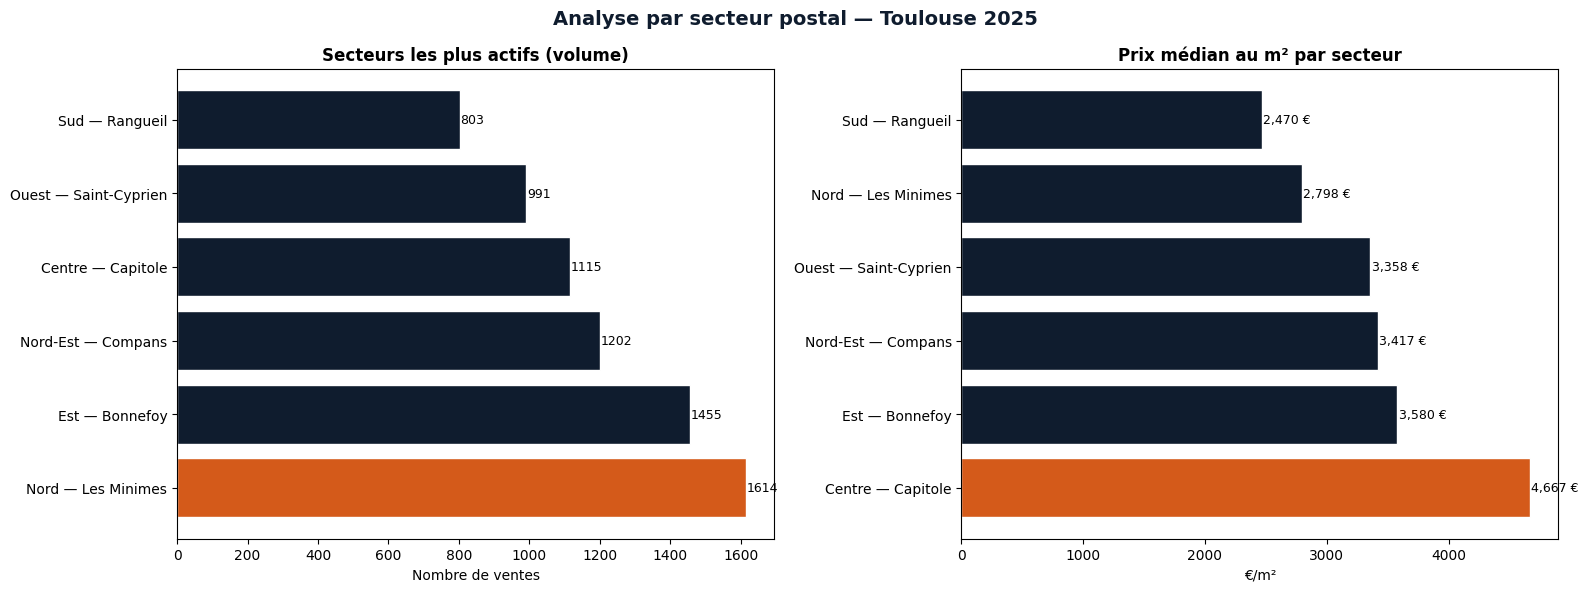

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse par secteur postal — Toulouse 2025', fontsize=14, fontweight='bold', color=NAVY)

secteur_stats = df.groupby('secteur').agg(
    nb_ventes   = ('id_mutation', 'count'),
    prix_m2_med = ('prix_m2', 'median'),
    prix_med    = ('valeur_fonciere', 'median'),
).sort_values('nb_ventes', ascending=False).head(8)

# Volume par secteur
bars = axes[0].barh(secteur_stats.index, secteur_stats['nb_ventes'],
                    color=[CLAY if i==0 else NAVY for i in range(len(secteur_stats))],
                    edgecolor='white')
axes[0].set_title('Secteurs les plus actifs (volume)', fontweight='bold')
axes[0].set_xlabel('Nombre de ventes')
for bar, val in zip(bars, secteur_stats['nb_ventes']):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# Prix m² par secteur
secteur_prix = df.groupby('secteur')['prix_m2'].median().sort_values(ascending=False).head(8)
bars2 = axes[1].barh(secteur_prix.index, secteur_prix.values,
                     color=[CLAY if i==0 else NAVY for i in range(len(secteur_prix))],
                     edgecolor='white')
axes[1].set_title('Prix médian au m² par secteur', fontweight='bold')
axes[1].set_xlabel('€/m²')
for bar, val in zip(bars2, secteur_prix.values):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f} €', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analyse_secteurs.png', dpi=150, bbox_inches='tight')
plt.show()

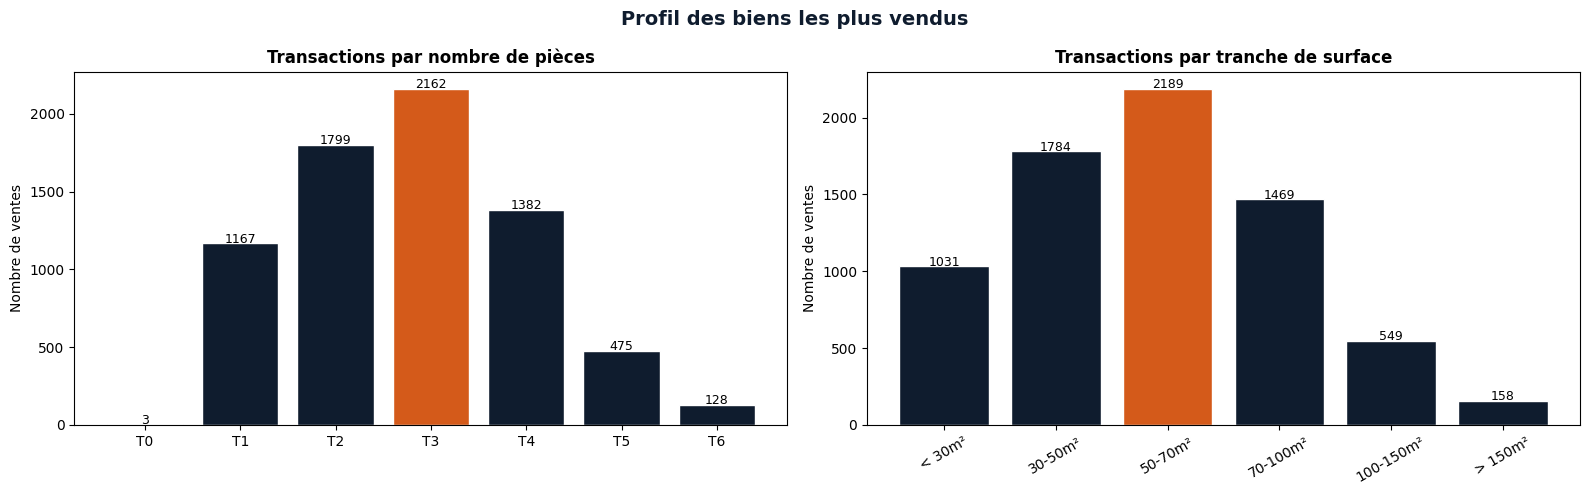

Type de bien le plus vendu : Appartement
Surface médiane vendue     : 60 m²
Nb pièces le plus fréquent : T3


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Profil des biens les plus vendus', fontsize=14, fontweight='bold', color=NAVY)

# Pièces les plus vendues
pieces_pop = df[df['nombre_pieces_principales'] <= 6]['nombre_pieces_principales'].value_counts().sort_index()
labels_pieces = [f'T{int(p)}' for p in pieces_pop.index]
axes[0].bar(labels_pieces, pieces_pop.values,
            color=[CLAY if v == pieces_pop.max() else NAVY for v in pieces_pop.values],
            edgecolor='white')
axes[0].set_title('Transactions par nombre de pièces', fontweight='bold')
axes[0].set_ylabel('Nombre de ventes')
for i, v in enumerate(pieces_pop.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Surface la plus vendue (tranches)
bins = [0, 30, 50, 70, 100, 150, 500]
labels_surf = ['< 30m²', '30-50m²', '50-70m²', '70-100m²', '100-150m²', '> 150m²']
df['tranche_surface'] = pd.cut(df['surface_reelle_bati'], bins=bins, labels=labels_surf)
surf_pop = df['tranche_surface'].value_counts().reindex(labels_surf)
axes[1].bar(labels_surf, surf_pop.values,
            color=[CLAY if v == surf_pop.max() else NAVY for v in surf_pop.values],
            edgecolor='white')
axes[1].set_title('Transactions par tranche de surface', fontweight='bold')
axes[1].set_ylabel('Nombre de ventes')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(surf_pop.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('analyse_biens_populaires.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Type de bien le plus vendu : {df["type_local"].value_counts().idxmax()}')
print(f'Surface médiane vendue     : {df["surface_reelle_bati"].median():.0f} m²')
print(f'Nb pièces le plus fréquent : T{int(df["nombre_pieces_principales"].mode()[0])}')

## 5. Évolution temporelle et prévisions

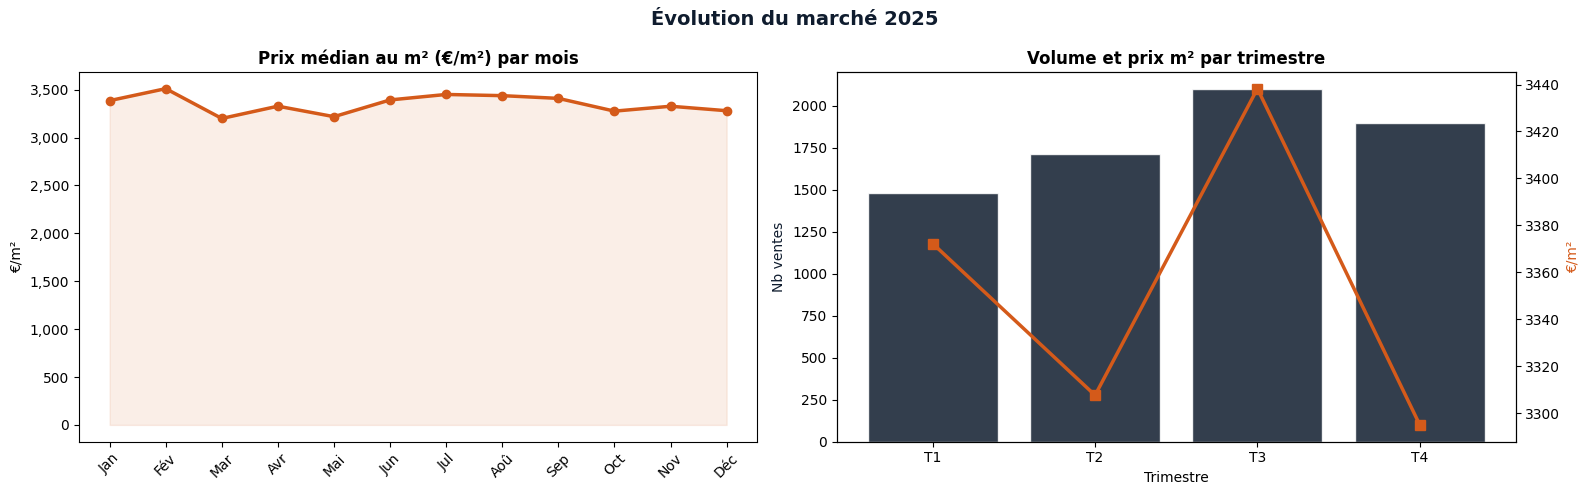

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Évolution du marché 2025', fontsize=14, fontweight='bold', color=NAVY)

# Prix m² médian par mois
monthly_prix = df.groupby('mois')['prix_m2'].median()
monthly_vol  = df.groupby('mois').size()

axes[0].plot(monthly_prix.index, monthly_prix.values,
             color=CLAY, linewidth=2.5, marker='o', markersize=6)
axes[0].fill_between(monthly_prix.index, monthly_prix.values,
                     alpha=0.1, color=CLAY)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'], rotation=45)
axes[0].set_title('Prix médian au m² (€/m²) par mois', fontweight='bold')
axes[0].set_ylabel('€/m²')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Volume par trimestre
trim_vol = df.groupby('trimestre').size()
trim_prix = df.groupby('trimestre')['prix_m2'].median()
x = trim_vol.index
bars = axes[1].bar(x, trim_vol.values, color=NAVY, edgecolor='white', alpha=0.85, label='Nb ventes')
ax2 = axes[1].twinx()
ax2.plot(x, trim_prix.values, color=CLAY, linewidth=2.5, marker='s', markersize=7, label='Prix m²')
axes[1].set_title('Volume et prix m² par trimestre', fontweight='bold')
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Nb ventes', color=NAVY)
ax2.set_ylabel('€/m²', color=CLAY)
axes[1].set_xticks([1,2,3,4])
axes[1].set_xticklabels(['T1','T2','T3','T4'])

plt.tight_layout()
plt.savefig('evolution_marche.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Modèle de prédiction du prix au m²

In [9]:
df_model = df[['prix_m2', 'surface_reelle_bati', 'nombre_pieces_principales',
               'type_local', 'secteur', 'trimestre']].dropna().copy()

le_type    = LabelEncoder()
le_secteur = LabelEncoder()
df_model['type_enc']    = le_type.fit_transform(df_model['type_local'])
df_model['secteur_enc'] = le_secteur.fit_transform(df_model['secteur'])

features = ['surface_reelle_bati', 'nombre_pieces_principales', 'type_enc', 'secteur_enc', 'trimestre']
X = df_model[features]
y = df_model['prix_m2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Régression linéaire
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Performances des modèles ===')
print(f'Régression linéaire — MAE : {mean_absolute_error(y_test, y_pred_lr):,.0f} €/m² | R² : {r2_score(y_test, y_pred_lr):.3f}')
print(f'Random Forest       — MAE : {mean_absolute_error(y_test, y_pred_rf):,.0f} €/m² | R² : {r2_score(y_test, y_pred_rf):.3f}')

=== Performances des modèles ===
Régression linéaire — MAE : 1,399 €/m² | R² : 0.088
Random Forest       — MAE : 1,364 €/m² | R² : 0.144


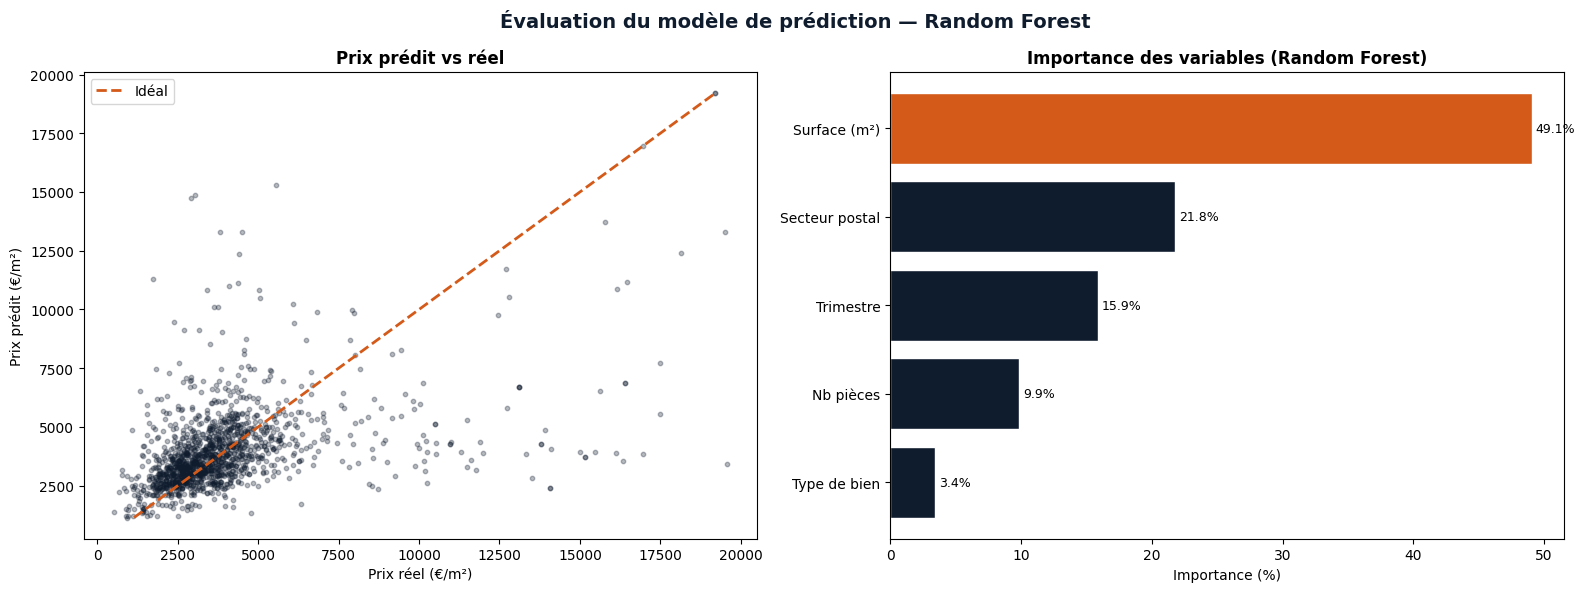

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Évaluation du modèle de prédiction — Random Forest', fontsize=14, fontweight='bold', color=NAVY)

# Prédit vs Réel
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color=NAVY, s=10)
lims = [max(y_test.min(), y_pred_rf.min()), min(y_test.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, color=CLAY, linewidth=2, linestyle='--', label='Idéal')
axes[0].set_xlabel('Prix réel (€/m²)')
axes[0].set_ylabel('Prix prédit (€/m²)')
axes[0].set_title('Prix prédit vs réel', fontweight='bold')
axes[0].legend()

# Importance des features
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
feat_labels = {
    'surface_reelle_bati': 'Surface (m²)',
    'nombre_pieces_principales': 'Nb pièces',
    'type_enc': 'Type de bien',
    'secteur_enc': 'Secteur postal',
    'trimestre': 'Trimestre'
}
feat_imp.index = [feat_labels[i] for i in feat_imp.index]
bars = axes[1].barh(feat_imp.index, feat_imp.values * 100,
                    color=[CLAY if v == feat_imp.max() else NAVY for v in feat_imp.values],
                    edgecolor='white')
axes[1].set_title('Importance des variables (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance (%)')
for bar, val in zip(bars, feat_imp.values * 100):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('prediction_modele.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print('=== Simulation de prédiction ===')
print()

exemples = [
    {'surface': 65, 'pieces': 3, 'type': 'Appartement', 'secteur': 'Toulouse 00', 'trim': 2},
    {'surface': 110, 'pieces': 5, 'type': 'Maison',      'secteur': 'Toulouse 00', 'trim': 3},
    {'surface': 35, 'pieces': 2, 'type': 'Appartement', 'secteur': 'Toulouse 00', 'trim': 1},
]

valid_secteurs = le_secteur.classes_
default_secteur = valid_secteurs[0]

for ex in exemples:
    secteur_val = ex['secteur'] if ex['secteur'] in valid_secteurs else default_secteur
    x_new = pd.DataFrame([{
        'surface_reelle_bati':       ex['surface'],
        'nombre_pieces_principales': ex['pieces'],
        'type_enc':    le_type.transform([ex['type']])[0],
        'secteur_enc': le_secteur.transform([secteur_val])[0],
        'trimestre':   ex['trim'],
    }])
    prix_m2_pred = rf.predict(x_new)[0]
    prix_total   = prix_m2_pred * ex['surface']
    print(f"  {ex['type']} T{ex['pieces']} de {ex['surface']}m²")
    print(f"  → Prix m² estimé : {prix_m2_pred:,.0f} €/m²")
    print(f"  → Prix total estimé : {prix_total:,.0f} €")
    print()

=== Simulation de prédiction ===

  Appartement T3 de 65m²
  → Prix m² estimé : 5,485 €/m²
  → Prix total estimé : 356,508 €

  Maison T5 de 110m²
  → Prix m² estimé : 5,985 €/m²
  → Prix total estimé : 658,373 €

  Appartement T2 de 35m²
  → Prix m² estimé : 6,850 €/m²
  → Prix total estimé : 239,735 €



## 7. Synthèse

In [12]:
print('=' * 55)
print('  SYNTHÈSE — Marché immobilier toulousain 2025')
print('=' * 55)
print()
print(f'  Transactions analysées : {len(df):,}')
print(f'  Dont appartements      : {len(df[df["type_local"]=="Appartement"]):,}')
print(f'  Dont maisons           : {len(df[df["type_local"]=="Maison"]):,}')
print()
print(f'  Prix médian            : {df["valeur_fonciere"].median():,.0f} €')
print(f'  Prix m² médian (appt)  : {df[df["type_local"]=="Appartement"]["prix_m2"].median():,.0f} €/m²')
print(f'  Prix m² médian (maison): {df[df["type_local"]=="Maison"]["prix_m2"].median():,.0f} €/m²')
print()
print(f'  Secteur le + actif     : {df.groupby("secteur").size().idxmax()}')
print(f'  Secteur le + cher      : {df.groupby("secteur")["prix_m2"].median().idxmax()}')
print(f'  Bien le + vendu        : {df["type_local"].value_counts().idxmax()}')
print(f'  Surface médiane vendue : {df["surface_reelle_bati"].median():.0f} m²')
print(f'  Mois le + actif        : {mois_labels[df.groupby("mois").size().idxmax()-1]}')
print()
print(f'  Modèle Random Forest   : R² = {r2_score(y_test, y_pred_rf):.3f}')
print(f'                           MAE = {mean_absolute_error(y_test, y_pred_rf):,.0f} €/m²')
print('=' * 55)

  SYNTHÈSE — Marché immobilier toulousain 2025

  Transactions analysées : 7,180
  Dont appartements      : 6,100
  Dont maisons           : 1,080

  Prix médian            : 173,925 €
  Prix m² médian (appt)  : 3,286 €/m²
  Prix m² médian (maison): 3,736 €/m²

  Secteur le + actif     : Nord — Les Minimes
  Secteur le + cher      : Centre — Capitole
  Bien le + vendu        : Appartement
  Surface médiane vendue : 60 m²
  Mois le + actif        : Jul

  Modèle Random Forest   : R² = 0.144
                           MAE = 1,364 €/m²


In [13]:
import json

meta = {
    "transactions": int(len(df)),
    "nb_appartements": int(len(df[df['type_local'] == 'Appartement'])),
    "nb_maisons": int(len(df[df['type_local'] == 'Maison'])),
    "prix_median_global": int(df['valeur_fonciere'].median()),
    "prix_m2_median_appart": int(df[df['type_local'] == 'Appartement']['prix_m2'].median()),
    "prix_m2_median_maison": int(df[df['type_local'] == 'Maison']['prix_m2'].median()),
    "secteur_plus_actif": df.groupby('secteur').size().idxmax(),
    "secteur_plus_cher": df.groupby('secteur')['prix_m2'].median().idxmax(),
    "mois_plus_actif": mois_labels[df.groupby('mois').size().idxmax() - 1],
}

secteurs_df = df[df['secteur'] != 'Autre']
secteur_agg = secteurs_df.groupby('secteur').agg(
    nb_ventes=('id_mutation', 'count'),
    prix_m2_med=('prix_m2', 'median'),
).reindex(list(quartiers.values())).fillna(0)

secteurs = {
    "labels": secteur_agg.index.tolist(),
    "prix_m2": [int(v) for v in secteur_agg['prix_m2_med']],
    "volumes": [int(v) for v in secteur_agg['nb_ventes']],
}

evolution = {
    "mois": mois_labels,
    "prix_m2_median": [int(monthly_prix.get(i, 0)) for i in range(1, 13)],
}

repartition = {
    "labels": ["Appartements", "Maisons"],
    "values": [int(len(df[df['type_local'] == 'Appartement'])), int(len(df[df['type_local'] == 'Maison']))],
}

pieces = {
    "labels": [f"T{int(p)}" for p in pieces_pop.index],
    "values": [int(v) for v in pieces_pop.values],
}

prediction = {
    "mae": int(round(mean_absolute_error(y_test, y_pred_rf))),
    "r2": round(r2_score(y_test, y_pred_rf), 3),
}

export_data = {
    "meta": meta,
    "secteurs": secteurs,
    "evolution": evolution,
    "repartition": repartition,
    "pieces": pieces,
    "prediction": prediction,
}

with open('market_analysis.json', 'w', encoding='utf-8') as f:
    json.dump(export_data, f, ensure_ascii=False, indent=2)

print(json.dumps(export_data, ensure_ascii=False, indent=2))

{
  "meta": {
    "transactions": 7180,
    "nb_appartements": 6100,
    "nb_maisons": 1080,
    "prix_median_global": 173925,
    "prix_m2_median_appart": 3285,
    "prix_m2_median_maison": 3736,
    "secteur_plus_actif": "Nord — Les Minimes",
    "secteur_plus_cher": "Centre — Capitole",
    "mois_plus_actif": "Jul"
  },
  "secteurs": {
    "labels": [
      "Centre — Capitole",
      "Sud — Rangueil",
      "Nord — Les Minimes",
      "Ouest — Saint-Cyprien",
      "Est — Bonnefoy",
      "Nord-Est — Compans"
    ],
    "prix_m2": [
      4666,
      2469,
      2797,
      3357,
      3580,
      3417
    ],
    "volumes": [
      1115,
      803,
      1614,
      991,
      1455,
      1202
    ]
  },
  "evolution": {
    "mois": [
      "Jan",
      "Fév",
      "Mar",
      "Avr",
      "Mai",
      "Jun",
      "Jul",
      "Aoû",
      "Sep",
      "Oct",
      "Nov",
      "Déc"
    ],
    "prix_m2_median": [
      3385,
      3510,
      3199,
      3327,
      3218,
      